# Fruit Disease Detection
---
Detect healthy or rotten fruits using image classification and deep learning (Convolutional Neural Networks) in Keras.

## 📘 Introduction

Fruit diseases can seriously affect crop quality and yield. Early detection can help prevent spread and reduce damage. In this project, we use deep learning and computer vision to identify diseases in fruits using image classification.

---

##  Dataset

We used the **Fruit and Vegetable Diseases Dataset**. It contains labeled images of healthy and diseased fruits and vegetables, organized into folders:

- Apple__Healthy
- Apple__Rotten
- Potato__Early_Blight
- Potato__Late_Blight
- Tomato__Healthy
- Tomato__Late_Blight  
...and more.

Each folder name is the label for its images.

---

## Image Preprocessing

Before training the model, all images were:
- Resized to a fixed shape (e.g., 64x64 pixels)
- Normalized to scale pixel values between 0 and 1
- Split into training and testing sets

We also used `ImageDataGenerator` to automate loading and preprocessing from folders.

---

## CNN Model Architecture

We used a **Convolutional Neural Network (CNN)** built with Keras. The model includes:
- Convolutional Layers (for feature extraction)
- MaxPooling Layers (to reduce spatial size)
- Flatten Layer (to flatten the output)
- Dense Layers (for classification)

The final layer uses **softmax activation** to predict the class probabilities.

---

## Model Training

We compiled the model with:
- **Loss**: `categorical_crossentropy`
- **Optimizer**: `adam`
- **Metrics**: `accuracy`

The model was trained for several epochs, and we observed that both training and validation accuracy improved over time.

---

## Model Testing

We tested the model using new fruit images. The model predicts the class and gives the probabilities for all classes.

---

## Sample Prediction

We tested the model with a healthy apple image.





**Import Required Libraries**

Explanation:

* **os, numpy:** File handling and numerical operations.

* **matplotlib.pyplot:** To visualize training performance.

* **tensorflow.keras:** To build and train the CNN model.

In [4]:
# Basic libraries
import os
import numpy as np
import matplotlib.pyplot as plt

# TensorFlow and Keras modules
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing import image



**Set Dataset Path and Image Parameters**

We define the image dimensions and batch size to load the images consistently.

In [6]:
# Path to the dataset folder
dataset_path = "C:/Users/iflah/Fruit And Vegetable Diseases Dataset"

# Image settings
img_height, img_width = 100, 100
batch_size = 32


**Load and Preprocess the Dataset**

* Images are normalized to values between 0 and 1.

* The dataset is split into training (80%) and validation (20%).



In [8]:
# Create an ImageDataGenerator with validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Load training data
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

# Load validation data
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 23430 images belonging to 28 classes.
Found 5846 images belonging to 28 classes.


**Build the CNN Model**

* **Conv2D** layers extract features from images.

* **MaxPooling2D** reduces image size to focus on* main features.

* **Dropout** helps prevent overfitting.

* **Final layer** uses softmax for multi-class classification.



In [10]:
# Define the CNN architecture
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

# Model structure summary
model.summary()


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,333,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,356,700 (16.62 MB)

 Trainable params: 4,356,700 (16.62 MB)

 Non-trainable params: 0 (0.00 B)

**Train the CNN Model**

The model is trained for 10 epochs while tracking accuracy and loss for both training and validation datasets.

In [13]:
# Set number of epochs
epochs = 10

# Train the model
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)


C:\ProgramData\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 23/733 ━━━━━━━━━━━━━━━━━━━━ 7:48 660ms/step - accuracy: 0.0754 - loss: 3.6857

C:\ProgramData\anaconda3\Lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


733/733 ━━━━━━━━━━━━━━━━━━━━ 732s 998ms/step - accuracy: 0.3334 - loss: 2.3234 - val_accuracy: 0.6447 - val_loss: 1.2492
Epoch 2/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 637s 869ms/step - accuracy: 0.6153 - loss: 1.2554 - val_accuracy: 0.7364 - val_loss: 0.9110
Epoch 3/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 592s 807ms/step - accuracy: 0.6952 - loss: 0.9832 - val_accuracy: 0.7568 - val_loss: 0.8851
Epoch 4/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 549s 750ms/step - accuracy: 0.7502 - loss: 0.7833 - val_accuracy: 0.7631 - val_loss: 0.8625
Epoch 5/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 515s 703ms/step - accuracy: 0.7829 - loss: 0.6711 - val_accuracy: 0.7961 - val_loss: 0.7236
Epoch 6/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 509s 694ms/step - accuracy: 0.8186 - loss: 0.5601 - val_accuracy: 0.8036 - val_loss: 0.7250
Epoch 7/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 561s 765ms/step - accuracy: 0.8335 - loss: 0.4972 - val_accuracy: 0.7988 - val_loss: 0.7837
Epoch 8/10
733/733 ━━━━━━━━━━━━━━━━━━━━ 552s 753ms/step - accuracy: 0.8524 - loss: 0.44

**Plot Accuracy and Loss Graphs**

These graphs help visualize model performance and detect overfitting or underfitting.

In [13]:
from keras.models import load_model

# Load the trained model (use the correct path to your saved file)
model = load_model('fruit_disease_model.h5')


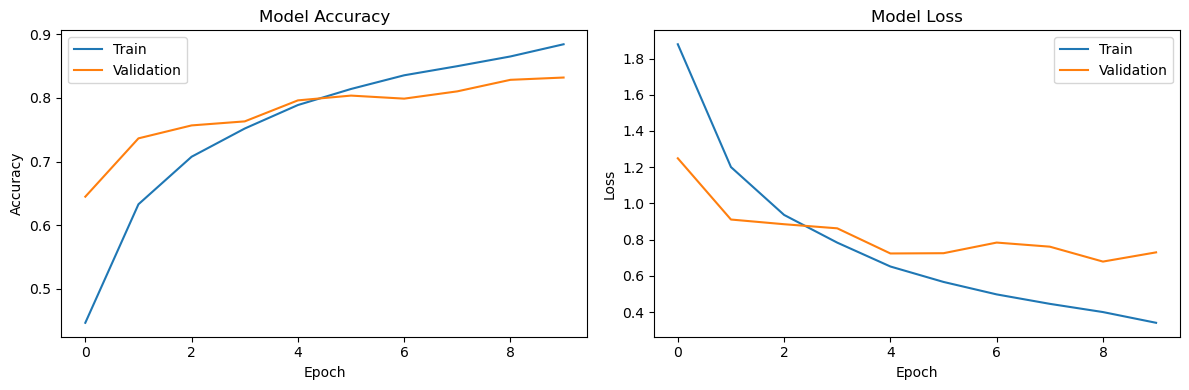

In [17]:
# Accuracy Plot
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


**Predict on a New Image**

This block loads a test image, prepares it, and predicts its class using the trained model.

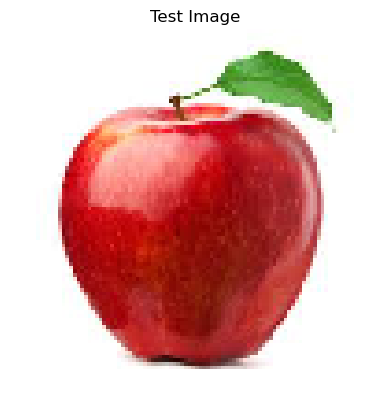

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
Predicted Class: Apple__Healthy
Prediction Probabilities: [[9.9964583e-01 2.8966175e-04 5.5264956e-14 8.3612969e-12 1.4777653e-06
  4.1353262e-05 4.6715577e-16 2.7891620e-17 1.7014746e-14 2.0213939e-19
  1.1122355e-18 1.2554131e-20 4.3312403e-14 3.5737416e-16 6.8067672e-20
  2.5436458e-22 1.8310939e-09 7.1252219e-11 5.9961662e-09 1.7752683e-09
  2.7201276e-07 5.8508537e-10 7.2140941e-15 5.4990074e-15 1.1857028e-09
  1.3860912e-14 1.5785332e-05 5.4713178e-06]]


In [17]:
import matplotlib.pyplot as plt

# ✅ Give the exact image filename here
test_image_path = r"C:\Users\iflah\Fruit And Vegetable Diseases Dataset\Apple__Healthy\apple.jpg"

# ✅ Load and preprocess the image
img = image.load_img(test_image_path, target_size=(img_height, img_width))

# ✅ Show the image
plt.imshow(img)
plt.axis('off')
plt.title("Test Image")
plt.show()

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# ✅ Predict the class
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

# ✅ Get class label names
class_labels = list(train_generator.class_indices.keys())

# ✅ Show result
print(f"Predicted Class: {class_labels[predicted_class]}")
print("Prediction Probabilities:", prediction)


---